In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [4]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/larsen0966/student-performance-data-set/student-por.csv


In [5]:
df = pd.read_csv('/kaggle/input/datasets/larsen0966/student-performance-data-set/student-por.csv', sep=';')

print(df.head())

  school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0  GP,"F",18,"U","GT3","A",4,4,"at_home","teacher...                                                                                                                                                                                 
1  GP,"F",17,"U","GT3","T",1,1,"at_home","other",...                                                                                                                                                                                 
2  GP,"F",15,"U","LE3","T",1,1,"at_home","other",...                                                                                                                                                                                 
3  GP,"F",15,"U","GT3","T",4,2,"health","services...                            

In [12]:
import pandas as pd

df = pd.read_csv(
    '/kaggle/input/datasets/larsen0966/student-performance-data-set/student-por.csv'
)

print(df.columns)

X = df[['G1', 'G2', 'G3', 'studytime', 'failures', 'absences']]

print(X.head())

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3'],
      dtype='object')
   G1  G2  G3  studytime  failures  absences
0   0  11  11          2         0         4
1   9  11  11          2         0         2
2  12  13  12          2         0         6
3  14  14  14          3         0         0
4  11  13  13          2         0         0


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print('Explained Variance Ratio:')
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.5170687  0.16923432]


In [15]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)

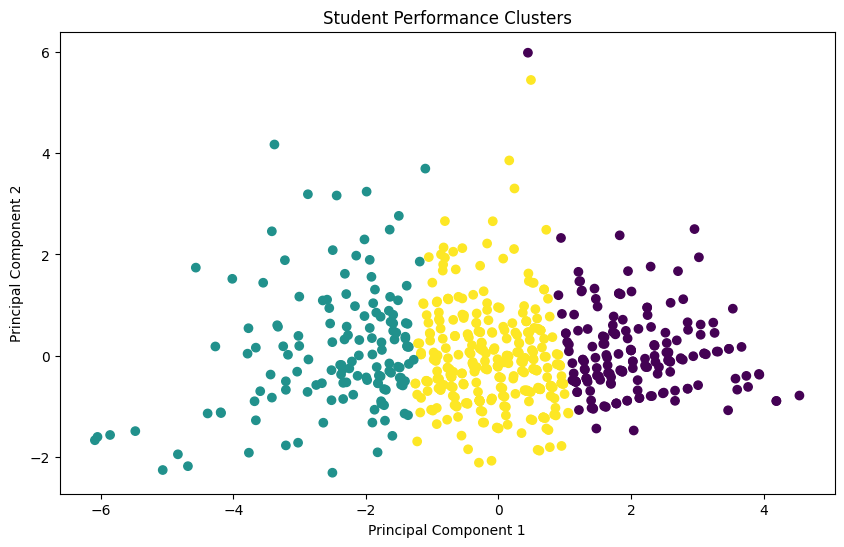

In [16]:
plt.figure(figsize=(10,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title('Student Performance Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.show()